In [ ]:
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#путь к папке с корпусом (лемматизированный корпус)
path = '/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/100women.txt'
dirs = os.listdir(path)

In [ ]:
i = 0
# словарь с именем файла и меткой класса (например, название рубрики или значение тональности)
dict_score = {}

In [ ]:
for file in dirs:
    #есть нетекстовые файлы
    if (file[-4:] == '.txt'):
        with open(path + '/' + file, 'r', encoding='utf-8') as readfile:
            for line in readfile:
                list_words = line.split()
                # последним токеном в файле идёт оценка = для текстов отзывов
                dict_score[file] = list_words[len(list_words)-1]
                # формируем файл для анализа
                with open('reviews_for_work.txt', 'a', encoding='utf-8') as wfile:
                    # первым токеном в файле идёт номер файла, он не нужен
                    wfile.write(' '.join(list_words[1:len(list_words) - 1]) + '\n')
                    i += 1

In [ ]:
print(f'files: {i}')

In [ ]:
print(f'dict_score: {len(dict_score)}')

# Methods

##N-gram

In [ ]:
import re
import math
import pandas as pd
import nltk

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/100women.txt', 'r', encoding='utf-8') as file: #файл с текстом
    f = file.read()

In [ ]:
text_words_2 = re.findall(r'[а-яёА-ЯЁ]+', f)

text_words_1 = [] #список с декапитализированными словами
for i in text_words_2:
    k = i.lower()
    text_words_1.append(k)

text_words_2

['ОТ',
 'АВТОРА',
 'Скажем',
 'сразу',
 'мы',
 'выбрали',
 'задачу',
 'нелёгкую',
 'женщин',
 'великих',
 'не',
 'так',
 'много',
 'как',
 'нам',
 'бы',
 'хотелось',
 'Известных',
 'что',
 'называется',
 'на',
 'слуху',
 'пруд',
 'пруди',
 'А',
 'вот',
 'великих',
 'Величественных',
 'А',
 'главное',
 'на',
 'века',
 'Таких',
 'может',
 'персон',
 'с',
 'уверенностью',
 'наберётся',
 'а',
 'остальным',
 'предстоит',
 'ещё',
 'разбираться',
 'с',
 'историей',
 'с',
 'её',
 'памятью',
 'Конечно',
 'имена',
 'Жанны',
 'д',
 'Арк',
 'или',
 'Сафо',
 'сомнений',
 'не',
 'вызывают',
 'Но',
 'кого',
 'можно',
 'поставить',
 'с',
 'ними',
 'рядом',
 'из',
 'наших',
 'современниц',
 'Возможно',
 'кому',
 'то',
 'представленный',
 'в',
 'книге',
 'список',
 'женских',
 'имён',
 'покажется',
 'неубедительным',
 'и',
 'спорным',
 'Одним',
 'из',
 'критериев',
 'при',
 'выборе',
 'имён',
 'было',
 'желание',
 'как',
 'можно',
 'шире',
 'представить',
 'спектр',
 'деятельности',
 'в',
 'котором',
 '

In [ ]:
text_words_1

['от',
 'автора',
 'скажем',
 'сразу',
 'мы',
 'выбрали',
 'задачу',
 'нелёгкую',
 'женщин',
 'великих',
 'не',
 'так',
 'много',
 'как',
 'нам',
 'бы',
 'хотелось',
 'известных',
 'что',
 'называется',
 'на',
 'слуху',
 'пруд',
 'пруди',
 'а',
 'вот',
 'великих',
 'величественных',
 'а',
 'главное',
 'на',
 'века',
 'таких',
 'может',
 'персон',
 'с',
 'уверенностью',
 'наберётся',
 'а',
 'остальным',
 'предстоит',
 'ещё',
 'разбираться',
 'с',
 'историей',
 'с',
 'её',
 'памятью',
 'конечно',
 'имена',
 'жанны',
 'д',
 'арк',
 'или',
 'сафо',
 'сомнений',
 'не',
 'вызывают',
 'но',
 'кого',
 'можно',
 'поставить',
 'с',
 'ними',
 'рядом',
 'из',
 'наших',
 'современниц',
 'возможно',
 'кому',
 'то',
 'представленный',
 'в',
 'книге',
 'список',
 'женских',
 'имён',
 'покажется',
 'неубедительным',
 'и',
 'спорным',
 'одним',
 'из',
 'критериев',
 'при',
 'выборе',
 'имён',
 'было',
 'желание',
 'как',
 'можно',
 'шире',
 'представить',
 'спектр',
 'деятельности',
 'в',
 'котором',
 '

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/swl.txt', 'r', encoding='utf8') as swl: #NEED STOP-WORDS LIST
    swlist = []  # список стоп-слов из файла
    for i in swl:
        i = i.replace('\n','')
        swlist.append(i)
        # print(swlist)

len(swlist)

941

In [ ]:
!pip install pymorphy2
import pymorphy2
morph = pymorphy2.MorphAnalyzer()

  Using cached pymorphy2-0.9.1-py3-none-any.whl (55 kB)
  Using cached DAWG_Python-0.7.2-py2.py3-none-any.whl (11 kB)
  Using cached pymorphy2_dicts_ru-2.4.417127.4579844-py2.py3-none-any.whl (8.2 MB)
  Using cached docopt-0.6.2.tar.gz (25 kB)
  Preparing metadata (setup.py) ... done
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=7cd65590b3f2a06bcf2f281e9328a380291293c2e4e87369797e0bcec0f03e9e
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt


In [ ]:
text_words = [] #список без стоп-слов
for i in text_words_1:
    i = morph.parse(i)[0].normal_form
    if i not in swlist:
        text_words.append(i)

text_words

['автор',
 'скажем',
 'сразу',
 'выбрать',
 'задача',
 'нелёгкая',
 'женщина',
 'великий',
 'хотеться',
 'известный',
 'называться',
 'слух',
 'пруд',
 'прудить',
 'великий',
 'величественный',
 'главное',
 'век',
 'персона',
 'уверенность',
 'набраться',
 'предстоять',
 'ещё',
 'разбираться',
 'история',
 'память',
 'имя',
 'жанна',
 'далее',
 'арк',
 'сафо',
 'сомнение',
 'вызывать',
 'можно',
 'поставить',
 'рядом',
 'современница',
 'возможно',
 'представить',
 'книга',
 'список',
 'женский',
 'имя',
 'показаться',
 'неубедительный',
 'спорный',
 'критерий',
 'выбор',
 'имя',
 'желание',
 'можно',
 'широкий',
 'представить',
 'спектр',
 'деятельность',
 'представительница',
 'слабый',
 'пол',
 'занять',
 'место',
 'сонм',
 'избранный',
 'знаменитый',
 'актриса',
 'писательница',
 'великий',
 'балерина',
 'певица',
 'бесконечный',
 'множество',
 'биография',
 'свободно',
 'сложиться',
 'хотеться',
 'показать',
 'женский',
 'сущность',
 'чрезвычайно',
 'разнообразный',
 'женский',
 '

In [ ]:
len(text_words)

101271

In [ ]:
frequency={}
for word in text_words:  # рассчитываем частоты слов
    count = frequency.get(word,0)  # создаём словарь СЛОВО и ЧАСТОТА
    frequency[word] = count + 1  # увеличиваем ЧАСТОТУ при считывании одинаковых лемм слова

frequency

{'автор': 42,
 'скажем': 6,
 'сразу': 51,
 'выбрать': 24,
 'задача': 21,
 'нелёгкая': 6,
 'женщина': 447,
 'великий': 211,
 'хотеться': 24,
 'известный': 94,
 'называться': 33,
 'слух': 29,
 'пруд': 4,
 'прудить': 1,
 'величественный': 3,
 'главное': 34,
 'век': 132,
 'персона': 8,
 'уверенность': 24,
 'набраться': 1,
 'предстоять': 12,
 'ещё': 313,
 'разбираться': 5,
 'история': 171,
 'память': 35,
 'имя': 189,
 'жанна': 31,
 'далее': 22,
 'арк': 10,
 'сафо': 36,
 'сомнение': 28,
 'вызывать': 39,
 'можно': 125,
 'поставить': 51,
 'рядом': 45,
 'современница': 6,
 'возможно': 62,
 'представить': 61,
 'книга': 122,
 'список': 16,
 'женский': 116,
 'показаться': 29,
 'неубедительный': 1,
 'спорный': 4,
 'критерий': 2,
 'выбор': 27,
 'желание': 51,
 'широкий': 17,
 'спектр': 1,
 'деятельность': 47,
 'представительница': 4,
 'слабый': 30,
 'пол': 44,
 'занять': 22,
 'место': 100,
 'сонм': 2,
 'избранный': 7,
 'знаменитый': 140,
 'актриса': 168,
 'писательница': 78,
 'балерина': 54,
 'певиц

In [ ]:
freq = sorted(frequency.items(), key=lambda x:x[1], reverse = True) #создаём список, в котором пары СЛОВО и ЧАСТОТА упорядочены по убыванию
length = len(text_words)

print(length)
print(freq)

101271
[('год', 1043), ('жизнь', 647), ('стать', 559), ('человек', 480), ('женщина', 447), ('время', 429), ('мария', 327), ('ещё', 313), ('уже', 311), ('мать', 282), ('муж', 259), ('новый', 258), ('день', 251), ('дом', 237), ('ребёнок', 227), ('большой', 226), ('отец', 217), ('семья', 216), ('знать', 214), ('великий', 211), ('любовь', 210), ('молодой', 205), ('друг', 200), ('дочь', 197), ('мир', 193), ('девушка', 192), ('имя', 189), ('дело', 187), ('героиня', 186), ('девочка', 186), ('жена', 184), ('русский', 180), ('сила', 175), ('сказать', 173), ('история', 171), ('оказаться', 171), ('иметь', 169), ('актриса', 168), ('театр', 168), ('смерть', 165), ('собственный', 165), ('сестра', 163), ('роль', 161), ('королева', 158), ('сын', 155), ('рука', 155), ('сцена', 154), ('писать', 147), ('судьба', 145), ('казаться', 144), ('жить', 144), ('конец', 143), ('знаменитый', 140), ('говорить', 139), ('однажды', 139), ('слово', 137), ('получить', 137), ('последний', 137), ('маленький', 136), ('хоро

In [ ]:
n_list=[]
for words in freq:  # проверяем каждую пару СЛОВО и ЧАСТОТА в отсортированном тексте
    fr_lst = list(words) # превращаем пары в круглых скобках, созданные анонимной функцией LAMBDA, в список из двух элементов - СЛОВО и ЧАСТОТА
    n_list.append(fr_lst)

n_list

[['год', 1043],
 ['жизнь', 647],
 ['стать', 559],
 ['человек', 480],
 ['женщина', 447],
 ['время', 429],
 ['мария', 327],
 ['ещё', 313],
 ['уже', 311],
 ['мать', 282],
 ['муж', 259],
 ['новый', 258],
 ['день', 251],
 ['дом', 237],
 ['ребёнок', 227],
 ['большой', 226],
 ['отец', 217],
 ['семья', 216],
 ['знать', 214],
 ['великий', 211],
 ['любовь', 210],
 ['молодой', 205],
 ['друг', 200],
 ['дочь', 197],
 ['мир', 193],
 ['девушка', 192],
 ['имя', 189],
 ['дело', 187],
 ['героиня', 186],
 ['девочка', 186],
 ['жена', 184],
 ['русский', 180],
 ['сила', 175],
 ['сказать', 173],
 ['история', 171],
 ['оказаться', 171],
 ['иметь', 169],
 ['актриса', 168],
 ['театр', 168],
 ['смерть', 165],
 ['собственный', 165],
 ['сестра', 163],
 ['роль', 161],
 ['королева', 158],
 ['сын', 155],
 ['рука', 155],
 ['сцена', 154],
 ['писать', 147],
 ['судьба', 145],
 ['казаться', 144],
 ['жить', 144],
 ['конец', 143],
 ['знаменитый', 140],
 ['говорить', 139],
 ['однажды', 139],
 ['слово', 137],
 ['получить', 137

In [ ]:
k = 1
for i in n_list:
    logfr = math.log(int(i[1]),10)
    logrank = math.log(k, 10)  # берём десятичные логарифмы для ранга и для частоты
    i.append(k)
    i.append(logfr)
    i.append(logrank)
    k+=1

In [ ]:
n_list

[['год', 1043, 1, 3.0182843084265305, 0.0],
 ['жизнь', 647, 2, 2.8109042806687, 0.30102999566398114],
 ['стать', 559, 3, 2.747411807886423, 0.47712125471966244],
 ['человек', 480, 4, 2.681241237375587, 0.6020599913279623],
 ['женщина', 447, 5, 2.650307523131936, 0.6989700043360187],
 ['время', 429, 6, 2.632457292184724, 0.7781512503836435],
 ['мария', 327, 7, 2.514547752660286, 0.8450980400142567],
 ['ещё', 313, 8, 2.4955443375464483, 0.9030899869919434],
 ['уже', 311, 9, 2.492760389026837, 0.9542425094393249],
 ['мать', 282, 10, 2.450249108319361, 1.0],
 ['муж', 259, 11, 2.4132997640812515, 1.041392685158225],
 ['новый', 258, 12, 2.41161970596323, 1.0791812460476247],
 ['день', 251, 13, 2.3996737214810375, 1.1139433523068367],
 ['дом', 237, 14, 2.374748346010104, 1.1461280356782377],
 ['ребёнок', 227, 15, 2.3560258571931225, 1.1760912590556811],
 ['большой', 226, 16, 2.3541084391474008, 1.2041199826559246],
 ['отец', 217, 17, 2.3364597338485296, 1.2304489213782739],
 ['семья', 216, 18

In [ ]:
frame = pd.DataFrame(n_list, columns=['Words','Frequencies','Ranks', 'Logarithm of Frequencies', 'Logarithm of ranks']) # собираем фрейм
frame.to_csv('Frequency Dictionary.csv',encoding='utf-8', sep=';', index=False) #экспортируем в файл

In [ ]:
frame

,Words,Frequencies,Ranks,Logarithm of Frequencies,Logarithm of ranks
0,год,1043,1,3.018284,0.000000
1,жизнь,647,2,2.810904,0.301030
2,стать,559,3,2.747412,0.477121
3,человек,480,4,2.681241,0.602060
4,женщина,447,5,2.650308,0.698970
...,...,...,...,...,...
16299,отверзтись,1,16300,0.000000,4.212188
16300,воскреснуть,1,16301,0.000000,4.212214
16301,богоматерить,1,16302,0.000000,4.212241
16302,учреждаться,1,16303,0.000000,4.212268


In [ ]:
bigrams = nltk.collocations.BigramAssocMeasures()
trigrams = nltk.collocations.TrigramAssocMeasures()

bigramFinder = nltk.collocations.BigramCollocationFinder.from_words(text_words)
trigramFinder = nltk.collocations.TrigramCollocationFinder.from_words(text_words)

# bigrams
bigram_freq = bigramFinder.ngram_fd.items()
bigramFreqTable = pd.DataFrame(list(bigram_freq), columns=['bigram','freq']).sort_values(by='freq', ascending=False)
bigramFreqTable.to_csv('Bigrams.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

# trigrams
trigram_freq = trigramFinder.ngram_fd.items()
trigramFreqTable = pd.DataFrame(list(trigram_freq), columns=['trigram','freq']).sort_values(by='freq', ascending=False)
trigramFreqTable.to_csv('Trigrams.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

In [ ]:
bigram_freq

In [ ]:
# t-test
bigramTtable = pd.DataFrame(list(bigramFinder.score_ngrams(bigrams.student_t)), columns=['bigram','T-test']).sort_values(by='T-test', ascending=False)
trigramTtable = pd.DataFrame(list(trigramFinder.score_ngrams(trigrams.student_t)), columns=['trigram','T-test']).sort_values(by='T-test', ascending=False)
bigramTtable = bigramTtable.head(20)
trigramTtable = trigramTtable.head(20) #вычленяем первые 20 лучших би- и триграмм
bigramTtable.to_csv('Bigrams-T-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл
trigramTtable.to_csv('Trigrams-T-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

# chi-squared
bigramCHItable = pd.DataFrame(list(bigramFinder.score_ngrams(bigrams.chi_sq)), columns=['bigram','Chi-squared']).sort_values(by='Chi-squared', ascending=False)
trigramCHItable = pd.DataFrame(list(trigramFinder.score_ngrams(trigrams.chi_sq)), columns=['trigram','Chi-squared']).sort_values(by='Chi-squared', ascending=False)
bigramCHItable = bigramCHItable.head(20)
trigramCHItable = trigramCHItable.head(20) #вычленяем первые 20 лучших би- и триграмм
bigramCHItable.to_csv('Bigrams-CHI-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл
trigramCHItable.to_csv('Trigrams-CHI-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

# log-likelihood
bigramlikelihoodtable = pd.DataFrame(list(bigramFinder.score_ngrams(bigrams.likelihood_ratio)), columns=['bigram','Log-Likelihood']).sort_values(by='Log-Likelihood', ascending=False)
trigramlikelihoodtable = pd.DataFrame(list(trigramFinder.score_ngrams(trigrams.likelihood_ratio)), columns=['trigram','Log-Likelihood']).sort_values(by='Log-Likelihood', ascending=False)
bigramlikelihoodtable = bigramlikelihoodtable.head(20)
trigramlikelihoodtable = trigramlikelihoodtable.head(20) #вычленяем первые 20 лучших би- и триграмм
bigramlikelihoodtable.to_csv('Bigrams-likelihood-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл
trigramlikelihoodtable.to_csv('Trigrams-likelihood-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

# pmi
bigramPMItable = pd.DataFrame(list(bigramFinder.score_ngrams(bigrams.pmi)), columns=['bigram','PMI']).sort_values(by='PMI', ascending=False)
trigramPMItable = pd.DataFrame(list(trigramFinder.score_ngrams(trigrams.pmi)), columns=['trigram','PMI']).sort_values(by='PMI', ascending=False)
bigramPMItable = bigramPMItable.head(20)
trigramPMItable = trigramPMItable.head(20) #вычленяем первые 20 лучших би- и триграмм
bigramPMItable.to_csv('Bigrams-PMI-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл
trigramPMItable.to_csv('Trigrams-PMI-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

##RAKE

In [ ]:
import pymorphy2 as pm
import codecs
import string

In [ ]:
m = pm.MorphAnalyzer()

In [ ]:
words = []
words2 = ""

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/100women.txt', 'r', encoding='utf-8') as f: #прописываем путь к корпусу (папка или файл)
    text = f.read()
    words = text.split()
    for i in range(len(words) - 1): #распознает в тексте знаменательные слова и КВ
        if m.parse(words[i])[0].tag.POS == "ADVB" or m.parse(words[i])[0].tag.POS == "VERB" or m.parse(words[i][:-1])[0].tag.POS == "VERB" or m.parse(words[i])[0].tag.POS == "PRTS"or m.parse(words[i])[0].tag.POS == "INFN"or m.parse(words[i])[0].tag.POS == "COMP" or m.parse(words[i])[0].tag.POS == "ADJS" or m.parse(words[i])[0].tag.POS == "GRND"or m.parse(words[i])[0].tag.POS == "CONJ":
            words2 += " | " + words[i] + " | "
        elif (m.parse(words[i])[0].tag.POS == "NOUN" and m.parse(words[i])[0].tag.case == ("gent" or "accs")):
            words2 += words[i] + " | "
        elif m.parse(words[i])[0].tag.POS == "NOUN" and m.parse(words[i + 1])[0].tag.POS == ("NOUN" or "ADJF") and m.parse(words[i])[0].tag.case != m.parse(words[i + 1])[0].tag.case and m.parse(words[i + 1])[0].tag.case != "gent":
            words2 += words[i] + " | "
        elif (m.parse(words[i])[0].tag.POS == "NOUN" and m.parse(words[i])[0].tag.case != ("nomn" or "accs") and m.parse(words[i + 1])[0].tag.POS == "NOUN" and m.parse(words[i + 1])[0].tag.case == ("nomn" or "accs")):
            words2 += words[i] + " | "
        elif (m.parse(words[i])[0].tag.POS == None and m.parse(words[i][:-1])[0].tag.POS == None and m.parse(words[i][1:])[0].tag.POS == None):
            words2 += " | " + words[i] + " | "
        elif (m.parse(words[i])[0].tag.POS == "NOUN" and m.parse(words[i - 1])[0].tag.POS == "ADJF" or m.parse(words[i - 1])[0].tag.POS == "PRTF") and m.parse(words[i])[0].tag.case == m.parse(words[i + 1])[0].tag.case:
            words2 += words[i] + " | "
        else:
            words2 += words[i] + " "

# чем длиннее выражение, тем больше у него вес

In [ ]:
words2

'ОТ АВТОРА |  | Скажем | сразу, мы  | выбрали | задачу нелёгкую  | — | женщин | великих не  | так | много,  | как | нам бы  | хотелось. | Известных,  | что |  | называется | «на слуху»  | — | пруд  | пруди! |  | А | вот великих… Величественных…  | А | главное, на века… Таких,  | может, |  | 15—20 | персон | с уверенностью  | наберётся, |  | а | остальным  | предстоит |  | ещё |  | разбираться | с историей, с  | её | памятью. Конечно, имена Жанны | д\'Арк  | или | Сафо  | сомнений | не  | вызывают. |  | Но | кого можно  | поставить | с ними  | рядом | из наших современниц? Возможно, кому-то представленный в книге | список женских имён |  | покажется | неубедительным  | и | спорным. Одним из критериев | при выборе имён |  | было | желание  | как | можно  | шире |  | представить | спектр деятельности, в котором представительницы слабого пола |  | могут |  | занять | своё место среди сонма | избранных. Знаменитые актрисы |  | и | писательницы, великие балерины |  | и | певицы |  | — | их б

In [ ]:
with open('corpus***.txt', 'w', encoding='utf-8') as f2:
    f2.write(words2)

In [ ]:
from __future__ import division
import operator
import nltk

In [ ]:
punct = open("stopwords/punct.txt", 'r', encoding='utf-8').read()

In [ ]:
punct_list = nltk.word_tokenize(punct)

In [ ]:
stop = open("stopwords/stop.txt", 'r', encoding='utf-8').read()

In [ ]:
pronouns = open("stopwords/pronouns.txt", 'r', encoding='utf-8').read()

In [ ]:
preps = open("stopwords/preps.txt", 'r', encoding='utf-8').read()

In [ ]:
preps

'а-ля\nбез\nбезо\nблагодаря\nблиз\nв\nвблизи\nввиду\nвглубь\nвдогон\nвдоль\nвзамен\nвключая\nвкруг\nвместо\nвне\nвнизу\nвнутри\nвнутрь\nво\nво имя\nвовнутрь\nвозле\nвокруг\nвопреки\nвослед\nвпереди\nвразрез\nвроде\nвслед\nвследствие\nдля\nдля-ради\nдо\nза\nзаместо\nиз\nиз-за\nиз-под\nизнутри\nизо\nк\nкасательно\nко\nкроме\nкругом\nмеж\nмежду\nмимо\nна\nнаверху\nнавроде\nнавстречу\nнад\nнадо\nназад\nнакануне\nнаперекор\nнаперерез\nнаподобие\nнапротив\nнасупротив\nнасчёт\nниже\nо\nоб\nобо\nобок\nоколо\nокрест\nокромя\nокруг\nопосля\nот\nотносительно\nото\nперед\nпередо\nпо\nпо-за\nпо-над\nпо-под\nповерх\nпод\nподле\nподо\nподобно\nпозади\nпозднее\nпомимо\nпоперёд\nпоперёк\nпорядка\nпосередине\nпосередь\nпосле\nпосреди\nпосредине\nпосредством\nпред\nпредо\nпрежде\nпри\nпро\nпротив\nпутём\nради\nс\nсверх\nсверху\nсвыше\nсзади\nсквозь\nскрозь\nснизу\nсо\nсогласно\nспустя\nсреди\nсредь\nсродни\nсупротив\nчерез\nчрез\n'

In [ ]:
mystop = open("stopwords/userstop.txt", 'r', encoding='utf-8').read()

In [ ]:
#nltk.word_tokenize(preps.decode("utf8")) + nltk.word_tokenize(mystop.decode("utf8"))
nltk.word_tokenize(preps) + nltk.word_tokenize(mystop)

['а-ля',
 'без',
 'безо',
 'благодаря',
 'близ',
 'в',
 'вблизи',
 'ввиду',
 'вглубь',
 'вдогон',
 'вдоль',
 'взамен',
 'включая',
 'вкруг',
 'вместо',
 'вне',
 'внизу',
 'внутри',
 'внутрь',
 'во',
 'во',
 'имя',
 'вовнутрь',
 'возле',
 'вокруг',
 'вопреки',
 'вослед',
 'впереди',
 'вразрез',
 'вроде',
 'вслед',
 'вследствие',
 'для',
 'для-ради',
 'до',
 'за',
 'заместо',
 'из',
 'из-за',
 'из-под',
 'изнутри',
 'изо',
 'к',
 'касательно',
 'ко',
 'кроме',
 'кругом',
 'меж',
 'между',
 'мимо',
 'на',
 'наверху',
 'навроде',
 'навстречу',
 'над',
 'надо',
 'назад',
 'накануне',
 'наперекор',
 'наперерез',
 'наподобие',
 'напротив',
 'насупротив',
 'насчёт',
 'ниже',
 'о',
 'об',
 'обо',
 'обок',
 'около',
 'окрест',
 'окромя',
 'округ',
 'опосля',
 'от',
 'относительно',
 'ото',
 'перед',
 'передо',
 'по',
 'по-за',
 'по-над',
 'по-под',
 'поверх',
 'под',
 'подле',
 'подо',
 'подобно',
 'позади',
 'позднее',
 'помимо',
 'поперёд',
 'поперёк',
 'порядка',
 'посередине',
 'посередь',
 

In [ ]:
stop_list = nltk.word_tokenize(stop) + nltk.word_tokenize(pronouns) + nltk.word_tokenize(preps) + nltk.word_tokenize(mystop)

In [ ]:
def isPunct(word):
  return len(word) == 1 and (word in string.punctuation or word in punct_list)

In [ ]:
def isNumeric(word):
  try:
    float(word) if '.' in word else int(word)
    return True
  except ValueError:
    return False

In [ ]:
def isInitial(word):
  return len(word) == 2 and word[1] == "."

In [ ]:
class RakeKeywordExtractor:

  def __init__(self):
    self.stopwords = set(nltk.corpus.stopwords.words())
    self.top_fraction = 1 # consider top third candidate keywords by score

  def _generate_candidate_keywords(self, sentences):
    phrase_list = []
    for sentence in sentences:
      words = map(lambda x: "|" if x in self.stopwords or x in stop_list or isNumeric(x) or isInitial(x) else x,
        nltk.word_tokenize(sentence.lower()))
      phrase = []
      for word in words:
        if word == "|" or isPunct(word):
          if len(phrase) > 0:
            phrase_list.append(phrase)
            phrase = []
        else:
          phrase.append(word)
    return phrase_list
## СТОП!!
  def _calculate_word_scores(self, phrase_list):
    word_freq = nltk.FreqDist()
    word_degree = nltk.FreqDist()
    for phrase in phrase_list:
      #degree = len(filter(lambda x: not isNumeric(x), phrase)) - 1
      degree = len(list(filter(lambda x: not isNumeric(x), phrase))) - 1
      for word in phrase:
        word_freq[word] += 1 ## word_fd.inc(word.lower()) with word_fd[word.lower()] += 1
        word_degree[word] += degree # other words
    for word in word_freq.keys():
      word_degree[word] = word_degree[word] + word_freq[word] # itself
    # word score = deg(w) / freq(w)
    word_scores = {}
    for word in word_freq.keys():
      word_scores[word] = word_degree[word] / word_freq[word]
    return word_scores

  def _calculate_phrase_scores(self, phrase_list, word_scores):
    phrase_scores = {}
    for phrase in phrase_list:
      phrase_score = 0
      for word in phrase:
        phrase_score += word_scores[word]
      phrase_scores[" ".join(phrase)] = phrase_score
    return phrase_scores

  def extract(self, text, incl_scores=False):
    sentences = nltk.sent_tokenize(text)
    phrase_list = self._generate_candidate_keywords(sentences)
    word_scores = self._calculate_word_scores(phrase_list)
    phrase_scores = self._calculate_phrase_scores(
      phrase_list, word_scores)
    #sorted_phrase_scores = sorted(phrase_scores.iteritems(),
    sorted_phrase_scores = sorted(phrase_scores.items(),
      key=operator.itemgetter(1), reverse=True)
    n_phrases = len(sorted_phrase_scores)
    if incl_scores:
      return sorted_phrase_scores[0:int(n_phrases/self.top_fraction)]
    else:
      return map(lambda x: x[0],
        sorted_phrase_scores[0:int(n_phrases/self.top_fraction)])

In [ ]:
rake = RakeKeywordExtractor()

In [ ]:
with open('D:\dialogues7.txt', 'r', encoding='utf-8') as f:
    txt = f.read()

In [ ]:
keywords = rake.extract(txt, incl_scores=True)

In [ ]:
for eachkwrd in keywords:
    print(eachkwrd[0], eachkwrd[1])

правильных позиций решают вопрос семейной жизни авторы лев ошанин 57.71976090014064
александр володин кастручча трагикомедия картина первая комната удивляет расцветкой 46.297916666666666
иного нестерпимый зной летнего полдня застает распростертым 46.0
милый взгляд твоих дивных глазенок пробудил впечатленье 37.26893939393939
клубных небесах заливался эстрадный оркестрик тех лет 36.87301587301587
вашему вниманию предлагается массовая старинная русская игра 36.83333333333333
тамара грустно листала странички писем карла маркса 33.163636363636364
умелые ловцы рыбы заостренными палками шарят 31.833333333333336
древности торговцы драгоценностями держали камни негранеными 31.333333333333332
знак почета лучшие куски мяса вручить охотникам 30.3
молодых строителей отряд растревожил сонное молчание 30.238095238095237
сумрачной квартирной глубины послышался мужской голос 29.86923076923077
неплохо усвоили роскошный стиль вашего любимого романа 29.154761904761905
женских голоса запели какую-то музыка

трибуне двое замшевых 6.711538461538462
материальная нагрузка… лямин 6.710031347962382
альдонса одновременно повернулись 6.708333333333333
люба съела конфетку 6.708333333333333
перегородку сами поставили 6.705314009661836
очень хорошие характеристики 6.702020202020202
радостно воскликнул похититель 6.70048309178744
живет полной жизнью 6.7
наташа ростова плохая 6.7
собственного большого самолюбия 6.7
красивее юных девушек 6.7
пришел разделить человека 6.698701298701298
люди снова заволновались 6.696581196581197
люди снова всполошились 6.696581196581197
счастлив моей любовью 6.696428571428571
старший брат поднялся 6.6949166394246475
хозяйство дело наживное 6.692028985507246
период совместной жизни 6.69198312236287
лениво проговорил красноречивый 6.691666666666667
глава подтолкнул ушастого 6.69002284843869
смогу обратиться дальше 6.689655172413794
хочу сделать дополнение 6.685990338164251
ждут наслаждения '' 6.685714285714285
братья карамазовы '' 6.685714285714285
человек боя клянусь 6.68

любовных переживаний 4.5
запер ящик 4.5
семи часов 4.5
вынужден попросить 4.5
верти шеей 4.5
половины шестого 4.5
приходилось выкручиваться 4.5
деревянный молоток 4.5
ляминым произошла 4.5
куплю холодильник 4.5
энергии потребляет 4.5
любы никулиной 4.5
николая степановича 4.5
ящерица несколько 4.5
моем телосложении 4.5
плавно перекатывающей 4.5
наблюдал скорпион 4.5
броситься прочь 4.5
предложил назвать 4.5
мелодично посмеиваясь 4.5
лягушки худосочные 4.5
заговорил медленно 4.5
изобразила ползущую 4.5
приоткрыв рот 4.5
окружной тропе 4.5
подсказали похитить 4.5
коротких копья 4.5
научным сотрудникам 4.5
дружеских связей 4.5
подарил кому-нибудь 4.5
станок поставь 4.5
человеческие страсти 4.5
снять напряжение 4.5
новую зеландию 4.5
обеда поспать 4.5
трудный день 4.5
щелкнул зажигалкой 4.5
станут знакомиться 4.5
добротного качества 4.5
преследовали враги 4.5
мажорный колорит 4.5
отбывать заключение 4.5
новую высоту 4.5
отвечаем хором 4.5
удивлением оборотились 4.5
лениво поплелась 4.5
ста

лихой наскок 4.0
ожидало приключение 4.0
странствующего рыцаря 4.0
слоновая кость 4.0
восхищаться ими 4.0
повытряхивала клиентов 4.0
ушлая девка 4.0
баклуши била 4.0
дону лопесу 4.0
дону умильосу 4.0
давайте-ка собираться 4.0
мамке-то скажу-у 4.0
обиталище добродетели 4.0
долы являли 4.0
распростертые ниц 4.0
пасет коз 4.0
подошвы скалы 4.0
раскаленном песке… 4.0
насладиться необычайной 4.0
расстеленной овчине 4.0
одинокие деревья 4.0
привлеченные громкостью 4.0
достойный пример 4.0
земной поверхности 4.0
штаны прожег 4.0
поделился едой 4.0
схватишь люмбаго 4.0
согнешься пополам 4.0
собственных подтяжках 4.0
нестриженой башкой 4.0
тяжкий грех 4.0
недостаточно образованы 4.0
исказилось рыданиями 4.0
ангелочек умирает 4.0
живо вобьешь 4.0
обещала радоваться 4.0
пылкого обожателя 4.0
выпрямлял кривду 4.0
карал дерзость 4.0
старых дев 4.0
легкомысленным священником 4.0
каждом шагу 4.0
какое-нибудь знамение 4.0
колодец греха 4.0
кладезь греха 4.0
кладезь распутства 4.0
угольная яма 4.0
начн

предполагаемый читатель 3.666666666666667
пишите записку 3.666666666666667
она-то спокойна 3.666666666666667
фантики играют 3.666666666666667
отставку получил 3.6666666666666665
учеников иисуса 3.6666666666666665
иисуса родила 3.6666666666666665
начал подозревать 3.6666666666666665
платить 3.6666666666666665
делал вид 3.6638655462184877
мир тебе 3.6636720943290286
хочешь взять 3.663636363636364
тамара играет 3.6636363636363636
тамара скрылась 3.6636363636363636
скоро придет 3.6635944700460827
саня открыл 3.663157894736842
свет дали 3.6628959276018103
дали свет 3.6628959276018103
г д 3.662344398340249
дали время 3.661443494776828
долгоносик влез 3.6610169491525424
оторопел долгоносик 3.6610169491525424
встрепенулся долгоносик 3.6610169491525424
сразу пойдем 3.6608946608946606
похититель подошел 3.6600790513833994
ходок бился 3.6595744680851063
восстал ходок 3.6595744680851063
воспылал ходок 3.6595744680851063
ходок занял 3.6595744680851063
ходок перебил 3.6595744680851063
сначала сидит 

...

похожи 1.5
обижают 1.5
вторжение 1.5
вдобавок 1.5
неловкость 1.5
извинения 1.5
помоложе 1.5
знаешь… 1.5
внезапно 1.5
разбираетесь 1.5
существовал 1.5
насмешка 1.5
благодарить 1.5
недовольны 1.5
благодарности 1.5
обращает 1.5
свободная 1.5
договориться 1.5
сменяются 1.5
рост 1.5
поклонник 1.5
стесняясь 1.5
котел 1.5
убивался 1.5
люди… 1.5
принял 1.5
симпатия 1.5
науки 1.5
возвращаться 1.5
поносил 1.5
мозги 1.5
отвратил 1.5
морочите 1.5
запинаясь 1.5
орать 1.5
наклонился 1.5
я… 1.5
истину 1.5
государь 1.5
преданный 1.5
дух 1.5
молодо 1.5
пожалеть 1.5
поклоняться 1.5
уважение 1.5
месту 1.5
первой 1.5
немолодой 1.5
барабаны 1.5
потерял 1.5
промолчал 1.5
чему-то 1.5
кривотолков 1.5
приглядела 1.5
стану 1.5
ушастому 1.5
договоритесь 1.5
усаживались 1.5
уселись 1.5
оплакивает 1.5
разом 1.5
показал 1.5
укорил 1.5
вину 1.5
беру 1.5
воображаю 1.5
подозрение 1.5
вдову 1.5
напал 1.5
наедине 1.5
дождалась 1.5
ловят 1.5
выяснять 1.5
вспомнить 1.5
останешься 1.5
водой 1.5
старался 1.5
здоров 1.5
пеще

вылетает 1.0
надумал 1.0
зоенька 1.0
синее 1.0
разорвись 1.0
потрепал 1.0
волосам 1.0
схожу 1.0
приду 1.0
слышно 1.0
встревожилась 1.0
выйдите 1.0
потихоньку 1.0
упало 1.0
корыто 1.0
повесьте 1.0
послушайте 1.0
раскрыла 1.0
недоверчиво 1.0
гулаг 1.0
несмотря 1.0
стоишь 1.0
проходи 1.0
садись 1.0
садитесь 1.0
пересел 1.0
достоинством 1.0
жалуюсь 1.0
ответственная 1.0
миленький 1.0
назовешь 1.0
упомнит 1.0
рангах 1.0
уважительно 1.0
подгорске 1.0
крупнейших 1.0
плавание 1.0
дисциплину 1.0
график 1.0
агитатор 1.0
вопросам 1.0
распускаются 1.0
лохматая 1.0
причешись 1.0
личиком 1.0
коммунисту 1.0
потребовать 1.0
партбюро 1.0
гордо 1.0
люси 1.0
технологическом 1.0
ненадолго 1.0
поживите 1.0
раскладушке 1.0
общем-то 1.0
условие 1.0
водить 1.0
закурил 1.0
курите 1.0
курю 1.0
позабыла 1.0
прихожую 1.0
карман 1.0
вешалке 1.0
ложитесь 1.0
помешаете 1.0
уговаривать 1.0
поколебался 1.0
скамеечку 1.0
охнула 1.0
обеспокоенный 1.0
обернулась 1.0
выключателю 1.0
подушку 1.0
затихла 1.0
прислушались 1.

бедненький 1.0
прости 1.0
бродила 1.0
потрогай 1.0
скамейку 1.0
кустам 1.0
маму 1.0
жаловалась 1.0
тощенькая 1.0
плечо 1.0
стрелочка 1.0
разводит 1.0
разлюбил 1.0
обнимая 1.0
успокоилась 1.0
продешевить 1.0
боязно 1.0
искала 1.0
стой 1.0
стукни 1.0
устоял 1.0
оторвалась 1.0
зовешь 1.0
выстроили 1.0
линейку 1.0
запаздывала 1.0
бегу 1.0
коридору 1.0
салюте 1.0
общежитие 1.0
помолчали 1.0
работаем 1.0
хорош 1.0
расхлябанность 1.0
безответственность 1.0
воспитываем 1.0
воздействуем 1.0
призываем 1.0
достоевский 1.0
прочитаешь 1.0
проживу 1.0
снимем 1.0
повестки 1.0
трудности 1.0
юрочка 1.0
сипло 1.0
решай 1.0
положиться 1.0
ошеломленный 1.0
совладал 1.0
напору 1.0
юрка 1.0
виноватый 1.0
возьмешь 1.0
аллочка 1.0
склонясь 1.0
разъезде 1.0
потрясен 1.0
поженились 1.0
обманывал 1.0
женат 1.0
чушь 1.0
бред 1.0
оборотень 1.0
хамелеон 1.0
намолчалась 1.0
позорь 1.0
пометался 1.0
личных 1.0
огорчила 1.0
отдай 1.0
ненавидя 1.0
пропустите 1.0
лицу 1.0
рыдала 1.0
несчастен 1.0
болгарию 1.0
ирка 1.0
т

поражена 1.0
пораженная 1.0
забредал 1.0
достойной 1.0
помыслов 1.0
отличалось 1.0
радом 1.0
возвышенным 1.0
ламанче 1.0
ть 1.0
вышло-то 1.0
позволил 1.0
сплетни 1.0
сплетен 1.0
поторговаться 1.0
вытягивай 1.0
ревнует 1.0
беснуется 1.0
ревновать-то 1.0
ревную 1.0
закругляться 1.0
вспомните 1.0
кладовку 1.0
надобны 1.0
помешали 1.0
дружище 1.0
объявить 1.0
заколдовали 1.0
альдонсой 1.0
оповещать 1.0
дурень 1.0
женишок 1.0
сказана 1.0
выгораживать 1.0
опомнись 1.0
поверил 1.0
сеновале 1.0
горах 1.0
матушка 1.0
доказательства 1.0
батюшка 1.0
удерживая 1.0
заткнись 1.0
раскаялась 1.0
мучился 1.0
хватил 1.0
скучные 1.0
овдоветь 1.0
преградив 1.0
бабка 1.0
драгоценней 1.0
безобразничай 1.0
пучеглазый 1.0
шерстью 1.0
гляди 1.0
обстригли 1.0
неволя 1.0
величайшее 1.0
несчастий 1.0
блажен 1.0
приостановить 1.0
образина 1.0
живодер 1.0
обставлена 1.0
отделана 1.0
выглядит 1.0
благородно 1.0
благородней 1.0
отыщутся 1.0
вопил 1.0
пустоголовая 1.0
запомнила 1.0
ланиты 1.0
неприличное 1.0
нтал 1.0


редакцию 1.0
заверил 1.0
спокоен 1.0
потревожу 1.0
выполни 1.0
покорнейше 1.0
мучительно 1.0
стенографистку 1.0
зайдите 1.0
отоприте 1.0
забросили 1.0
шкафом 1.0
обсуждался 1.0
секретаршей 1.0
зашелся 1.0
вынудил 1.0
беспамятстве 1.0
доставлю 1.0
управление 1.0
хорошо… 1.0
отпуска 1.0
взяться 1.0
отпрашиваетесь 1.0
разберусь 1.0
телевидению 1.0
освещен 1.0
ранен 1.0
вез 1.0
санях 1.0
рассказываете 1.0
заинтересовались 1.0
знаем… 1.0
все-таки… 1.0
горим 1.0
поэты 1.0
спорит… 1.0
никак… 1.0
чувствуя 1.0
склонен 1.0
уступкам 1.0
виду… 1.0
подумать… 1.0
обещал… 1.0
уговорила 1.0
побуду 1.0
справку 1.0
подготовила 1.0
официально 1.0
предупредила 1.0
нарушит 1.0
постыдились 1.0
извинитесь 1.0
заступайся 1.0
рассеянна 1.0
вероятнее 1.0
поедет 1.0
осложнять 1.0
преувеличиваю 1.0
делится 1.0
бедняге 1.0
пропускал 1.0
инструктор 1.0
спеленькая 1.0
фрукт 1.0
запротоколировано 1.0
дневнике 1.0
числам 1.0
стихия 1.0
отпрашиваются 1.0
направилась 1.0
уселся 1.0
утопая 1.0
страдая 1.0
распутать 1.0
ч

In [ ]:
keywords

[('правильных позиций решают вопрос семейной жизни авторы лев ошанин',
  57.71976090014064),
 ('александр володин кастручча трагикомедия картина первая комната удивляет расцветкой',
  46.297916666666666),
 ('иного нестерпимый зной летнего полдня застает распростертым', 46.0),
 ('милый взгляд твоих дивных глазенок пробудил впечатленье',
  37.26893939393939),
 ('клубных небесах заливался эстрадный оркестрик тех лет', 36.87301587301587),
 ('вашему вниманию предлагается массовая старинная русская игра',
  36.83333333333333),
 ('тамара грустно листала странички писем карла маркса', 33.163636363636364),
 ('умелые ловцы рыбы заостренными палками шарят', 31.833333333333336),
 ('древности торговцы драгоценностями держали камни негранеными',
  31.333333333333332),
 ('знак почета лучшие куски мяса вручить охотникам', 30.3),
 ('молодых строителей отряд растревожил сонное молчание', 30.238095238095237),
 ('сумрачной квартирной глубины послышался мужской голос', 29.86923076923077),
 ('неплохо усвоил

In [ ]:
with open('rake_keywords.csv', 'w', encoding='utf-8') as f2:
    for eachkwrd in keywords:
        f2.write(str(eachkwrd[0])+";"+str(eachkwrd[1])+"\n")

##KeyBERT

In [ ]:
!pip install keybert
import keybert

In [ ]:
from keybert import KeyBERT

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/100women.txt', 'r', encoding='utf-8') as f:
    doc = f.read()

In [ ]:
kw_model = KeyBERT()

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
keywords = kw_model.extract_keywords(doc)

In [ ]:
keywords

In [ ]:
keywords = kw_model.extract_keywords(doc, top_n=20)
keywords

In [ ]:
with open('KeyBERT_top_20.csv', 'w', encoding='utf-8') as f2:
    for eachkwrd in keywords:
        f2.write(str(eachkwrd[0])+";"+str(eachkwrd[1])+"\n")

In [ ]:
keywords = kw_model.extract_keywords(doc, keyphrase_ngram_range=(1, 2), top_n=20)
keywords

In [ ]:
with open('KeyBERT_top_20_bigram.csv', 'w', encoding='utf-8') as f2:
    for eachkwrd in keywords:
        f2.write(str(eachkwrd[0])+";"+str(eachkwrd[1])+"\n")

In [ ]:
keywords = kw_model.extract_keywords(doc, keyphrase_ngram_range=(1, 3), top_n=20)
keywords

In [ ]:
with open('KeyBERT_top_20_trigram.csv', 'w', encoding='utf-8') as f2:
    for eachkwrd in keywords:
        f2.write(str(eachkwrd[0])+";"+str(eachkwrd[1])+"\n")

##RuTermExtract

In [ ]:
!pip install rutermextract

  Preparing metadata (setup.py) ... done
  Created wheel for rutermextract: filename=rutermextract-0.3-py3-none-any.whl size=9706 sha256=1c292647ffd62417de55745d06da29bd0605d97eef41250d24baf7fb65532f18
  Stored in directory: /root/.cache/pip/wheels/44/00/bc/33a2ee393657898aed2be21b2598c4e2a7ababd404a2f979e1
Successfully built rutermextract


In [ ]:
from rutermextract import TermExtractor

In [ ]:
term_extractor = TermExtractor()

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/100women.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [ ]:
for term in term_extractor(text):
    print(term.normalized, term.count)

Streaming output truncated to the last 5000 lines.
великие княжны 1
великие итальянцы 1
великие имена 1
великие зодчие 1
великие злодейства 1
великая уланова 1
великая уланов 1
великая танцовщица 1
великая современница 1
великая правительница 1
великая поэтесса 1
великая повелительница 1
великая незнакомка 1
великая мадемуазель 1
великая кабалье 1
великая индианка 1
великая идея 1
великая женщина-политик 1
великая ермолов 1
великая держава 1
великая девственница 1
великая гречанка 1
великая государыня 1
великая государственность 1
вековая репертуар 1
век катаклизмов 1
век интеллекта 1
вездесущие журналисты 1
вежливая заинтересованность 1
вежливая беседа 1
ведущий борьба 1
ведущая актриса 1
ведомые дума 1
вдохновенный голос 1
вдохновенные стихотворения 1
вдохновенная фигурка 1
вдовый отец 1
вдовствующая царица 1
вдовая ленин 1
вдова полковника 1
введённая мария-антуанетта 1
ваши предложение 1
ваши пальцы 1
ваше ум 1
ваше письмо 1
ваше здоровье 1
ваша шляпа 1
ваша тоска 1
ваша супруга 1


In [ ]:
with open('RuTermExtract_keywords.csv', 'w', encoding='utf-8') as f2:
    for term in term_extractor(text):
        f2.write(str(term.normalized)+";"+str(term.count)+"\n")

##SpaCy

In [ ]:
!pip install spacy

In [ ]:
!pip install https://github.com/explosion/spacy-models/releases/download/ru_core_news_sm-3.1.0/ru_core_news_sm-3.1.0.tar.gz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 19.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 659.5/659.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 9.5 MB/s eta 0:00:00
  Created wheel for ru-core-news-sm: filename=ru_core_news_sm-3.1.0-py3-none-any.whl size=16086391 sha256=2647caa0a5a1e00d57b40e638f892389c5d0cf8d17ea40227ca799c77b7ce2bc
  Stored in directory: /root/.cache/pip/wheels/5c/20/2c/4830d46ba72a770a01170c2a94938f4fa770ad7781340ccc4b
Successfully built ru-core-news-sm
  Attempting uninstall: wasabi
    Found existing installation: wasabi 1.1.2
    Uninstalling wasabi-1.1.2:
      Successfully uninstalled wasabi-1.1.2
  Attempting uninstall: typer
    Found existing installation: typer 0.9.4
    Uninstallin

In [ ]:
import spacy
from collections import Counter
from nltk.corpus import stopwords

In [ ]:
# Для SpaCy (дополнительно взяли стоп-слова из nltk, с ними результаты улучшились)
spacy_model = spacy.load('ru_core_news_sm')

/usr/local/lib/python3.10/dist-packages/torch/__init__.py:696: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [ ]:
spacy_model.max_length = 2400000

In [ ]:
import nltk
nltk.download('stopwords')

In [ ]:
nltk_stopwords = stopwords.words('russian')

In [ ]:
spacy_stopwords = spacy_model.Defaults.stop_words

In [ ]:
def extract_keywords_with_spacy(text):
    keywords = []
    doc = spacy_model(text.read())
    for token in doc:
        # Тексты уже очищены от знаков препинания и лемматизированы, тем не менее, остались некоторые символы,
        # которые нужно удалить
        if token.text not in spacy_stopwords and token.text not in nltk_stopwords and \
                token.text not in "`'«»...—-":
            if token.pos_ in ('ADJ', 'NOUN', 'VERB'):
                keywords.append(token.text)

    freq_word = Counter(keywords)
    max_freq = Counter(keywords).most_common(1)[0][1]
    for w in freq_word:
        freq_word[w] = round(freq_word[w] / max_freq, 3)

    freq_20 = freq_word.most_common(20)

    with open('spacykeywords.csv', 'w', encoding='utf-8') as f2:
        for term in freq_20:
            f2.write(str(term[0])+";"+str(term[1])+"\n")

    print(freq_20)

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/100women.txt', 'r', encoding='utf-8') as file:
    extract_keywords_with_spacy(file)

[('жизни', 1.0), ('года', 0.839), ('лет', 0.78), ('время', 0.732), ('жизнь', 0.715), ('году', 0.644), ('стала', 0.61), ('женщина', 0.39), ('годы', 0.39), ('времени', 0.331), ('мать', 0.331), ('матери', 0.297), ('человека', 0.285), ('женщины', 0.282), ('день', 0.282), ('сказать', 0.28), ('смерти', 0.274), ('человек', 0.271), ('мужа', 0.268), ('любви', 0.266)]


##Pullenti

In [ ]:
!pip install pullenti_wrapper

In [ ]:
from pullenti_wrapper.processor import Processor, GEO, ORGANIZATION, PERSON, PHONE, ADDRESS
from collections import Counter

In [ ]:
pullenti_processor = Processor([PERSON, ORGANIZATION, GEO, PHONE, ADDRESS])

In [ ]:
def extract_keywords_with_pullenti(text):
    keywords = []
    for text in text.read().splitlines():
        try:
            result = pullenti_processor(text)
            for match in result.walk():
                for key, value in match.referent.slots:
                    if key not in ('ISRELATIVE', 'SEX', 'NUMBER', 'HIGHER', 'PROFILE',
                                   'ALPHA2', 'POINTER', 'FROM', 'REF', 'ATTRIBUTE'):
                        if 'LASTNAME' in str(match.referent.slots) and 'FIRSTNAME' in str(match.referent.slots):
                            try:
                                keywords.append(f'{match.referent.firstname} {match.referent.lastname}'.lower())
                            except AttributeError:
                                continue
                        keywords.append(str(value).lower())
        except ValueError:
            continue

    freq_word = Counter(keywords)

    freq_20 = freq_word.most_common(20)

    with open('pullenti_keywords.csv', 'w', encoding='utf-8') as f2:
        for term in freq_20:
            f2.write(str(term[0])+";"+str(term[1])+"\n")

    print(freq_20)

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/100women.txt', 'r', encoding='utf-8') as file:
    extract_keywords_with_pullenti(file)

KeyboardInterrupt: 

# EXPERIMENT

Вам нужно

а) выбрать себе одну статью,

б) выделить из нее КВ с помощью набора алгоритмов в тетрадке (можете добавить YAKE!, MultiRAKE),

в) сравнить результаты автоматического анализа и ручную разметку (определить, сколько КВ из эталона попало в результаты отдельных алгоритмов),

г) сохранить Ваш результат в папке Эксперимент https://drive.google.com/drive/folders/18Sk3Nen4YOta8aaSm1mzb-jNVnspt4AR?usp=drive_link

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/Pronoza_IMS_2015_rus.txt', 'r', encoding='utf-8') as file: #файл с текстом
    f = file.read()

## n-gram

In [ ]:
text_words_2 = re.findall(r'[а-яёА-ЯЁ]+', f)

text_words_1 = [] #список с декапитализированными словами
for i in text_words_2:
    k = i.lower()
    text_words_1.append(k)

text_words_2

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/swl.txt', 'r', encoding='utf8') as swl: #NEED STOP-WORDS LIST
    swlist = []  # список стоп-слов из файла
    for i in swl:
        i = i.replace('\n','')
        swlist.append(i)
        # print(swlist)

len(swlist)

In [ ]:
text_words = [] #список без стоп-слов
for i in text_words_1:
    i = morph.parse(i)[0].normal_form
    if i not in swlist:
        text_words.append(i)

text_words

In [ ]:
frequency={}
for word in text_words:  # рассчитываем частоты слов
    count = frequency.get(word,0)  # создаём словарь СЛОВО и ЧАСТОТА
    frequency[word] = count + 1  # увеличиваем ЧАСТОТУ при считывании одинаковых лемм слова

frequency

In [ ]:
freq = sorted(frequency.items(), key=lambda x:x[1], reverse = True) #создаём список, в котором пары СЛОВО и ЧАСТОТА упорядочены по убыванию
length = len(text_words)

print(length)
print(freq)

1787
[('словарь', 41), ('аспект', 39), ('признак', 38), ('отзыв', 31), ('анализ', 28), ('работа', 27), ('задача', 24), ('ресторан', 23), ('корпус', 23), ('классификатор', 23), ('тональность', 22), ('метод', 19), ('использоваться', 19), ('слово', 17), ('обучение', 16), ('качество', 15), ('дать', 14), ('текст', 14), ('машинный', 14), ('язык', 12), ('набор', 12), ('обслуживание', 12), ('мнение', 11), ('результат', 11), ('грамм', 11), ('система', 10), ('наивный', 10), ('байесовский', 10), ('основа', 9), ('модель', 9), ('например', 9), ('вектор', 9), ('хороший', 9), ('комбинация', 9), ('биграмм', 9), ('разметить', 9), ('еда', 9), ('значение', 9), ('решение', 8), ('использование', 8), ('подход', 8), ('использовать', 8), ('исследование', 8), ('эксперимент', 8), ('наречие', 8), ('модификатор', 8), ('несмежный', 8), ('предикативный', 8), ('атрибутивный', 8), ('выбор', 8), ('время', 7), ('являться', 7), ('автоматический', 7), ('позволять', 7), ('извлечение', 7), ('опорный', 7), ('проводиться', 7

In [ ]:
n_list=[]
for words in freq:  # проверяем каждую пару СЛОВО и ЧАСТОТА в отсортированном тексте
    fr_lst = list(words) # превращаем пары в круглых скобках, созданные анонимной функцией LAMBDA, в список из двух элементов - СЛОВО и ЧАСТОТА
    n_list.append(fr_lst)

n_list

In [ ]:
k = 1
for i in n_list:
    logfr = math.log(int(i[1]),10)
    logrank = math.log(k, 10)  # берём десятичные логарифмы для ранга и для частоты
    i.append(k)
    i.append(logfr)
    i.append(logrank)
    k+=1

In [ ]:
n_list #частотный словарь

In [ ]:
frame = pd.DataFrame(n_list, columns=['Words','Frequencies','Ranks', 'Logarithm of Frequencies', 'Logarithm of ranks']) # собираем фрейм
frame.to_csv('Frequency Dictionary.csv',encoding='utf-8', sep=';', index=False) #экспортируем в файл

In [ ]:
frame

,Words,Frequencies,Ranks,Logarithm of Frequencies,Logarithm of ranks
0,словарь,41,1,1.612784,0.000000
1,аспект,39,2,1.591065,0.301030
2,признак,38,3,1.579784,0.477121
3,отзыв,31,4,1.491362,0.602060
4,анализ,28,5,1.447158,0.698970
...,...,...,...,...,...
548,глагольный,1,549,0.000000,2.739572
549,выполнить,1,550,0.000000,2.740363
550,поддержка,1,551,0.000000,2.741152
551,грант,1,552,0.000000,2.741939


In [ ]:
bigrams = nltk.collocations.BigramAssocMeasures()
trigrams = nltk.collocations.TrigramAssocMeasures()

bigramFinder = nltk.collocations.BigramCollocationFinder.from_words(text_words)
trigramFinder = nltk.collocations.TrigramCollocationFinder.from_words(text_words)

# bigrams
bigram_freq = bigramFinder.ngram_fd.items()
bigramFreqTable = pd.DataFrame(list(bigram_freq), columns=['bigram','freq']).sort_values(by='freq', ascending=False)
bigramFreqTable.to_csv('Bigrams.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

# trigrams
trigram_freq = trigramFinder.ngram_fd.items()
trigramFreqTable = pd.DataFrame(list(trigram_freq), columns=['trigram','freq']).sort_values(by='freq', ascending=False)
trigramFreqTable.to_csv('Trigrams.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

In [ ]:
# t-test
bigramTtable = pd.DataFrame(list(bigramFinder.score_ngrams(bigrams.student_t)), columns=['bigram','T-test']).sort_values(by='T-test', ascending=False)
trigramTtable = pd.DataFrame(list(trigramFinder.score_ngrams(trigrams.student_t)), columns=['trigram','T-test']).sort_values(by='T-test', ascending=False)
bigramTtable = bigramTtable.head(20)
trigramTtable = trigramTtable.head(20) #вычленяем первые 20 лучших би- и триграмм
bigramTtable.to_csv('Bigrams-T-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл
trigramTtable.to_csv('Trigrams-T-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

# chi-squared
bigramCHItable = pd.DataFrame(list(bigramFinder.score_ngrams(bigrams.chi_sq)), columns=['bigram','Chi-squared']).sort_values(by='Chi-squared', ascending=False)
trigramCHItable = pd.DataFrame(list(trigramFinder.score_ngrams(trigrams.chi_sq)), columns=['trigram','Chi-squared']).sort_values(by='Chi-squared', ascending=False)
bigramCHItable = bigramCHItable.head(20)
trigramCHItable = trigramCHItable.head(20) #вычленяем первые 20 лучших би- и триграмм
bigramCHItable.to_csv('Bigrams-CHI-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл
trigramCHItable.to_csv('Trigrams-CHI-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

# log-likelihood
bigramlikelihoodtable = pd.DataFrame(list(bigramFinder.score_ngrams(bigrams.likelihood_ratio)), columns=['bigram','Log-Likelihood']).sort_values(by='Log-Likelihood', ascending=False)
trigramlikelihoodtable = pd.DataFrame(list(trigramFinder.score_ngrams(trigrams.likelihood_ratio)), columns=['trigram','Log-Likelihood']).sort_values(by='Log-Likelihood', ascending=False)
bigramlikelihoodtable = bigramlikelihoodtable.head(20)
trigramlikelihoodtable = trigramlikelihoodtable.head(20) #вычленяем первые 20 лучших би- и триграмм
bigramlikelihoodtable.to_csv('Bigrams-likelihood-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл
trigramlikelihoodtable.to_csv('Trigrams-likelihood-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл

# pmi
bigramPMItable = pd.DataFrame(list(bigramFinder.score_ngrams(bigrams.pmi)), columns=['bigram','PMI']).sort_values(by='PMI', ascending=False)
trigramPMItable = pd.DataFrame(list(trigramFinder.score_ngrams(trigrams.pmi)), columns=['trigram','PMI']).sort_values(by='PMI', ascending=False)
bigramPMItable = bigramPMItable.head(20)
trigramPMItable = trigramPMItable.head(20) #вычленяем первые 20 лучших би- и триграмм
bigramPMItable.to_csv('Bigrams-PMI-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл
trigramPMItable.to_csv('Trigrams-PMI-test-20.csv',encoding='utf8', sep=';', index=False) #экспортируем в файл


Биграммы/триграммы:


1.   likelihood-test: 3 из 4 эталонных КВ (не попало "отзывы о ресторанах")
2.   t-tests: 4 из 4 эталонных КВ
3.   PMI-test: 0 из 4 эталонных КВ
4.   CHI-test: 0 из 4 эталонных КВ



## RAKE

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/Pronoza_IMS_2015_Abstract_eng.txt', 'r', encoding='utf-8') as file: #файл с текстом
    file2 = file.read()

In [ ]:
!pip install rake-nltk

In [ ]:
import nltk
nltk.download('stopwords')

In [ ]:
nltk.download('punkt')

In [ ]:
from rake_nltk import Rake

# Uses stopwords for english from NLTK, and all puntuation characters by default
r = Rake()

# Extraction given the text.
r.extract_keywords_from_text(file2)

# Extraction given the list of strings where each string is a sentence.
# r.extract_keywords_from_sentences(<list of sentences>)

# To get keyword phrases ranked highest to lowest.
r.get_ranked_phrases()

['based approach towards sentiment analysis',
 'based restaurant sentiment analysis',
 'restaurant aspects classification models',
 'tourism recommender systems e',
 'identifying sentiment class',
 'tourism recommender systems',
 'various feature sets',
 'text understanding systems',
 'petersburg state university',
 'naïve bayes appears',
 'particular restaurant aspect',
 'recommender systems',
 'yagunova1 saint',
 'texts belong',
 'resources learnt',
 'proposed method',
 'paper presents',
 'logistic regression',
 'colloquial style',
 'reviews leads',
 'best choice',
 'e',
 'e',
 'e',
 'aspect',
 'aspect',
 'reviews',
 'best',
 'use',
 'unstructured',
 'svm',
 'shown',
 'series',
 'review',
 'restaurants',
 'respect',
 'relevance',
 'pronoza1',
 'improvement',
 'experiments',
 'deciding',
 'data',
 'corpus',
 'conduct',
 'classifiers',
 'applied']

In [ ]:
# To get keyword phrases ranked highest to lowest with scores.
r.get_ranked_phrases_with_scores()

[(23.0, 'based approach towards sentiment analysis'),
 (16.666666666666664, 'based restaurant sentiment analysis'),
 (15.666666666666666, 'restaurant aspects classification models'),
 (11.25, 'tourism recommender systems e'),
 (10.0, 'identifying sentiment class'),
 (9.5, 'tourism recommender systems'),
 (9.0, 'various feature sets'),
 (9.0, 'text understanding systems'),
 (9.0, 'petersburg state university'),
 (9.0, 'naïve bayes appears'),
 (8.333333333333332, 'particular restaurant aspect'),
 (6.0, 'recommender systems'),
 (4.0, 'yagunova1 saint'),
 (4.0, 'texts belong'),
 (4.0, 'resources learnt'),
 (4.0, 'proposed method'),
 (4.0, 'paper presents'),
 (4.0, 'logistic regression'),
 (4.0, 'colloquial style'),
 (3.5, 'reviews leads'),
 (3.5, 'best choice'),
 (1.75, 'e'),
 (1.75, 'e'),
 (1.75, 'e'),
 (1.6666666666666667, 'aspect'),
 (1.6666666666666667, 'aspect'),
 (1.5, 'reviews'),
 (1.5, 'best'),
 (1.0, 'use'),
 (1.0, 'unstructured'),
 (1.0, 'svm'),
 (1.0, 'shown'),
 (1.0, 'series'),

Rake: 2 из 4 эталонных КВ

При этом одно КВ расширено на 2 слова




## MultiRAKE

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/Pronoza_IMS_2015_rus.txt', 'r', encoding='utf-8') as file: #файл с текстом
    f = file.read()

In [ ]:
!pip install multi-rake

In [ ]:
s = set(swlist)

In [ ]:
from multi_rake import Rake

rake = Rake(
    min_chars=3,
    max_words=3,
    min_freq=1,
    language_code='ru',
    stopwords=s,
    lang_detect_threshold=50,
    max_words_unknown_lang=2,
    generated_stopwords_percentile=80,
    generated_stopwords_max_len=3,
    generated_stopwords_min_freq=2,
)

keywords = rake.apply(f)

print(keywords)

[('маркетинговой политики компании', 9.0), ('принадлежат разговорному стилю', 9.0), ('любых других задачах', 9.0), ('применении нейронных сетей', 9.0), ('требует семантических тезаурусов', 9.0), ('различными типами ядра', 9.0), ('которому относится отрицание', 9.0), ('отражающих синтаксические связи', 9.0), ('собой синтаксическими отношениями', 9.0), ('выражены различными способами', 9.0), ('используем вектора встречаемости', 9.0), ('длина отзыва варьируется', 9.0), ('удовлетворяют этому критерию', 9.0), ('точки зрения пользователей', 9.0), ('пытаясь извлечь максимум', 9.0), ('возможностей выбранного инструментария', 9.0), ('десятки процентов хуже', 9.0), ('средней взвешенной f-меры', 9.0), ('является оптимальным выбором', 9.0), ('средней взвешенной f1-меры', 9.0), ('методом опорных векторов', 8.857142857142858), ('задача анализа тональности', 8.833333333333334), ('делением размеченного корпуса', 8.75), ('расширения размеченного корпуса', 8.75), ('задаче анализа тональности', 8.6666666

In [ ]:
with open(r'/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/multirake_keywords.txt', 'w') as fp:
    for item in keywords:
        # write each item on a new line
        fp.write("%s\n" % str(item))
    print('Done')

Done


MultiRAKE: 3 из 4 эталонных КВ

*   не попало "отзывы о ресторанах"
*   не лемматизирует



## YAKE!

In [ ]:
!pip install git+https://github.com/LIAAD/yake

In [ ]:
import yake

kw_extractor = yake.KeywordExtractor()
keywords = kw_extractor.extract_keywords(f)

for kw in keywords:
	print(kw)

('для', 0.0052864387557584)
('анализа тональности отзывов', 0.010845671697828348)
('отзывов', 0.012363393217085796)
('анализа тональности', 0.012443549075826595)
('признаков', 0.012629068444672008)
('анализа', 0.014575005023843485)
('аспектов', 0.01591749812847145)
('Как', 0.01599743587106363)
('для анализа тональности', 0.019399150635671415)
('корпуса', 0.01990179228167918)
('корпуса отзывов', 0.02378753931546901)
('метод опорных векторов', 0.023966386356876486)
('тональности отзывов', 0.024035147618114105)
('данной работе', 0.024317522705022975)
('анализа корпуса', 0.024629748230664217)
('тональности', 0.025825793642482147)
('что', 0.026036027250400332)
('для машинного обучения', 0.029248678970140028)
('словарей', 0.029498244483184926)
('машинного обучения', 0.030007975244969322)


In [ ]:
language = "ru"
max_ngram_size = 2
deduplication_threshold = 0.9
deduplication_algo = 'seqm'
windowSize = 1
numOfKeywords = 20

custom_kw_extractor = yake.KeywordExtractor(lan=language, n=max_ngram_size, dedupLim=deduplication_threshold, dedupFunc=deduplication_algo, windowsSize=windowSize, top=numOfKeywords, features=None)
keywords = custom_kw_extractor.extract_keywords(f)

for kw in keywords:
    print(kw)

('анализа тональности', 0.009838159810925333)
('отзывов', 0.011057418715672573)
('признаков', 0.011346067055858175)
('анализа', 0.013057773844203325)
('аспектов', 0.01432108313172838)
('корпуса', 0.017960313794867632)
('корпуса отзывов', 0.018768814211054894)
('тональности отзывов', 0.018982173886591455)
('данной работе', 0.019447895680638802)
('анализа корпуса', 0.019454464596194283)
('тональности', 0.023331580097306775)
('машинного обучения', 0.024172306621158195)
('словарей', 0.0268274913464235)
('аспектов ресторана', 0.02808425805020389)
('данной', 0.029436230190032282)
('метод опорных', 0.02989437306857593)
('опорных векторов', 0.030739948108762034)
('работе', 0.031762648924349185)
('обслуживания', 0.032152122342807406)
('метод', 0.037051163783280654)


In [ ]:
language = "ru"
max_ngram_size = 3
deduplication_threshold = 0.9
deduplication_algo = 'seqm'
windowSize = 1
numOfKeywords = 20

custom_kw_extractor = yake.KeywordExtractor(lan=language, n=max_ngram_size, dedupLim=deduplication_threshold, dedupFunc=deduplication_algo, windowsSize=windowSize, top=numOfKeywords, features=None)
keywords = custom_kw_extractor.extract_keywords(f)

for kw in keywords:
    print(kw)

('анализа тональности отзывов', 0.007441867047154428)
('анализа тональности', 0.009838159810925333)
('отзывов', 0.011057418715672573)
('признаков', 0.011346067055858175)
('анализа', 0.013057773844203325)
('аспектов', 0.01432108313172838)
('метод опорных векторов', 0.017026603356149517)
('корпуса', 0.017960313794867632)
('корпуса отзывов', 0.018768814211054894)
('тональности отзывов', 0.018982173886591455)
('данной работе', 0.019447895680638802)
('анализа корпуса', 0.019454464596194283)
('метод анализа тональности', 0.022001772645530337)
('тональности', 0.023331580097306775)
('машинного обучения', 0.024172306621158195)
('основе корпуса отзывов', 0.02540676898141378)
('признаков машинного обучения', 0.025939431469148788)
('словарей', 0.0268274913464235)
('наивный байесовский классификатор', 0.027702490287737483)
('аспектов ресторана', 0.02808425805020389)


YAKE!:

*   2 из 4 эталонных КВ (не было отзывы о ресторанах, рекомендательная система)
*   не лемматизирует



## KeyBERT

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/Pronoza_IMS_2015_rus.txt', 'r', encoding='utf-8') as f:
    doc = f.read()

In [ ]:
kw_model = KeyBERT()

In [ ]:
keywords = kw_model.extract_keywords(doc, keyphrase_ngram_range=(1, 2), top_n=20)
keywords

[('определения релевантности', 0.4651),
 ('аспектно ориентированный', 0.4599),
 ('использование семантических', 0.4535),
 ('английского языка', 0.4534),
 ('автоматического понимания', 0.4522),
 ('университет katpronoza', 0.4506),
 ('извлечения информации', 0.4499),
 ('логистической регрессии', 0.4484),
 ('петербургский государственный', 0.4456),
 ('используемых семантических', 0.4442),
 ('размечен автоматически', 0.4439),
 ('аспектно ориентированного', 0.4421),
 ('отношении аспекта', 0.442),
 ('классификации аспекта', 0.44),
 ('автоматически или', 0.439),
 ('аспектов извлекаемых', 0.4381),
 ('описании аспекта', 0.4376),
 ('аспект скорости', 0.4371),
 ('словарей автоматически', 0.4335),
 ('классификатор бернуллиевский', 0.4335)]

In [ ]:
keywords = kw_model.extract_keywords(doc, keyphrase_ngram_range=(1, 3), top_n=20)
keywords

[('государственный университет katpronoza', 0.5009),
 ('отношении некоторых аспектов', 0.4959),
 ('университет katpronoza iagounova', 0.4908),
 ('рандомизированной логистической регрессии', 0.4883),
 ('используемых семантических ресурсов', 0.4818),
 ('относительно исследуемого аспекта', 0.4803),
 ('нерелевантные относительно исследуемого', 0.4802),
 ('исследуемых аспектов ресторана', 0.4787),
 ('представлен аспектно ориентированный', 0.4773),
 ('петербургский государственный университет', 0.4765),
 ('использование словарей автоматически', 0.4733),
 ('список аспектов извлекаемых', 0.4705),
 ('модификаторов усилителей состоящий', 0.4688),
 ('систем автоматического понимания', 0.4685),
 ('рассматривается применение синтаксических', 0.4685),
 ('при описании аспекта', 0.4684),
 ('применение синтаксических грамм', 0.4656),
 ('определения релевантности', 0.4651),
 ('синтаксических грамм состоящих', 0.4643),
 ('классификатор логистическая регрессия', 0.4643)]

KeyBERT: 0 из 4 эталонных КВ

## RuTermExtract

In [ ]:
term_extractor = TermExtractor()

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/Pronoza_IMS_2015_rus.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [ ]:
for term in term_extractor(text):
    print(term.normalized, term.count)

данная работа 10
машинное обучение 9
опорные векторы 7
качество еды 7
таблица 7
рестораны 7
отзывы 7
метод 7
наивный байесовский классификатор 6
признаки 6
обслуживание 6
аспекты 6
словарь тональностей 5
русский язык 5
предикативно-атрибутивные словари 5
набор признаков 5
эксперименты 5
результаты 5
наличие 5
сфера e-туризма 4
несмежные биграммы 4
машинный обучение 4
логистическая регрессия 4
целое 4
словари 4
работа 4
подкорпус 4
основа 4
классификаторы 4
выбор 4
время 4
n-граммы 4
аспектно-ориентированный метод анализа тональности отзывов 3
оценка покрытия корпуса 3
задача анализа тональности 3
частотное словарь 3
случайный лес 3
словари номинаций 3
рекомендательные системы 3
размеченный подкорпус 3
ключевые слова 3
извлечение мнений 3
дерево решений 3
степень 3
решение 3
применение 3
прилагательные 3
помощь 3
подход 3
перцептрон 3
перемешивание 3
качество 3
использование 3
автоматическое анализ мнений пользователей 2
основа корпуса отзывов 2
задача извлечения мнений 2
доступные линг

RuTermExtract: 3 из 4 эталонных КВ

не попало "отзывы о ресторанах"

## SpaCy

In [ ]:
spacy_model = spacy.load('ru_core_news_sm')

In [ ]:
spacy_model.max_length = 2400000

In [ ]:
nltk_stopwords = stopwords.words('russian')

In [ ]:
spacy_stopwords = spacy_model.Defaults.stop_words

In [ ]:
def extract_keywords_with_spacy(text):
    keywords = []
    doc = spacy_model(text.read())
    for token in doc:
        # Тексты уже очищены от знаков препинания и лемматизированы, тем не менее, остались некоторые символы,
        # которые нужно удалить
        if token.text not in spacy_stopwords and token.text not in nltk_stopwords and \
                token.text not in "`'«»...—-":
            if token.pos_ in ('ADJ', 'NOUN', 'VERB'):
                keywords.append(token.text)

    freq_word = Counter(keywords)
    max_freq = Counter(keywords).most_common(1)[0][1]
    for w in freq_word:
        freq_word[w] = round(freq_word[w] / max_freq, 3)

    freq_20 = freq_word.most_common(20)

    with open('spacykeywords.csv', 'w', encoding='utf-8') as f2:
        for term in freq_20:
            f2.write(str(term[0])+";"+str(term[1])+"\n")

    print(freq_20)

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/Pronoza_IMS_2015_rus.txt', 'r', encoding='utf-8') as file:
    extract_keywords_with_spacy(file)

[('признаков', 1.0), ('отзывов', 0.923), ('анализа', 0.808), ('аспектов', 0.808), ('корпуса', 0.692), ('тональности', 0.538), ('словарей', 0.538), ('данной', 0.462), ('работе', 0.462), ('обслуживания', 0.462), ('словаря', 0.423), ('обучения', 0.385), ('метод', 0.346), ('основе', 0.346), ('слов', 0.346), ('машинного', 0.346), ('еды', 0.346), ('−', 0.346), ('мнений', 0.308), ('работы', 0.308)]


SpaCy:

*   получились слова, а не биграммы
*   из полученных слов можно составить 2 из 4 эталонных КВ



In [ ]:
!pip install keyword-spacy

In [ ]:
!pip install spacy-transformers

In [ ]:
!python -m spacy download en_core_web_md

In [ ]:
import spacy
nlp = spacy.load("en_core_web_md")

In [ ]:
nlp.add_pipe("keyword_extractor", last=True, config={"top_n": 10, "min_ngram": 3, "max_ngram": 3, "strict": True, "top_n_sent": 3})

ValueError: [E002] Can't find factory for 'keyword_extractor' for language English (en). This usually happens when spaCy calls `nlp.create_pipe` with a custom component name that's not registered on the current language class. If you're using a Transformer, make sure to install 'spacy-transformers'. If you're using a custom component, make sure you've added the decorator `@Language.component` (for function components) or `@Language.factory` (for class components).

Available factories: attribute_ruler, tok2vec, merge_noun_chunks, merge_entities, merge_subtokens, token_splitter, parser, beam_parser, entity_linker, ner, beam_ner, entity_ruler, lemmatizer, tagger, morphologizer, senter, sentencizer, textcat, spancat, textcat_multilabel, ru.lemmatizer, en.lemmatizer

In [ ]:
doc = nlp(file2)
print("Top Document Keywords:", doc._.keywords)
for sent in doc.sents:
    print(f"Sentence: {sent.text}")
    print("Top Sentence Keywords:", sent._.sent_keywords)

AttributeError: [E046] Can't retrieve unregistered extension attribute 'keywords'. Did you forget to call the `set_extension` method?

## Pullenti

In [ ]:
pullenti_processor = Processor([PERSON, ORGANIZATION, GEO, PHONE, ADDRESS])

In [ ]:
def extract_keywords_with_pullenti(text):
    keywords = []
    for text in text.read().splitlines():
        try:
            result = pullenti_processor(text)
            for match in result.walk():
                for key, value in match.referent.slots:
                    if key not in ('ISRELATIVE', 'SEX', 'NUMBER', 'HIGHER', 'PROFILE',
                                   'ALPHA2', 'POINTER', 'FROM', 'REF', 'ATTRIBUTE'):
                        if 'LASTNAME' in str(match.referent.slots) and 'FIRSTNAME' in str(match.referent.slots):
                            try:
                                keywords.append(f'{match.referent.firstname} {match.referent.lastname}'.lower())
                            except AttributeError:
                                continue
                        keywords.append(str(value).lower())
        except ValueError:
            continue

    freq_word = Counter(keywords)

    freq_20 = freq_word.most_common(20)

    with open('pullenti_keywords.csv', 'w', encoding='utf-8') as f2:
        for term in freq_20:
            f2.write(str(term[0])+";"+str(term[1])+"\n")

    print(freq_20)

In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/мага1/сем_анализ/Pronoza_IMS_2015_rus.txt', 'r', encoding='utf-8') as file:
    extract_keywords_with_pullenti(file)

[('е проноза', 3), ('е ягунова', 3), ('е', 2), ('в', 2), ('университет', 2), ('санкт петербургский государственный университет', 2), ('спбгу', 2), ('проноза', 1), ('ягунова', 1), ('санкт-петербург', 1), ('город', 1)]


Pullenti:

*   0 из 4 эталонных КВ
*   есть подозрение, что он просмотрел только первый абзац




Результаты с портала Молодой ученый: 1 из 4 эталонных КВ

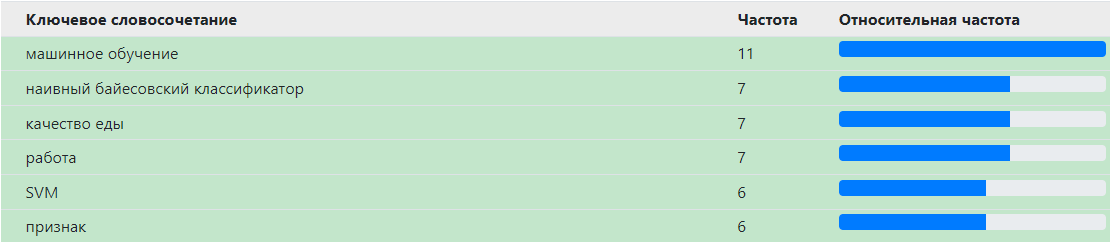

## Итоги

Из всех алгоритмов лучше справляются:

1.   n-gram (T-tests): 4/4
2.   MultiRAKE: 3/4
3.   RuTermExtract: 3/4

